# fig1_clone - Part 2/3\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


✅ 高亮 neuron tail2: ['01', '04', '05']


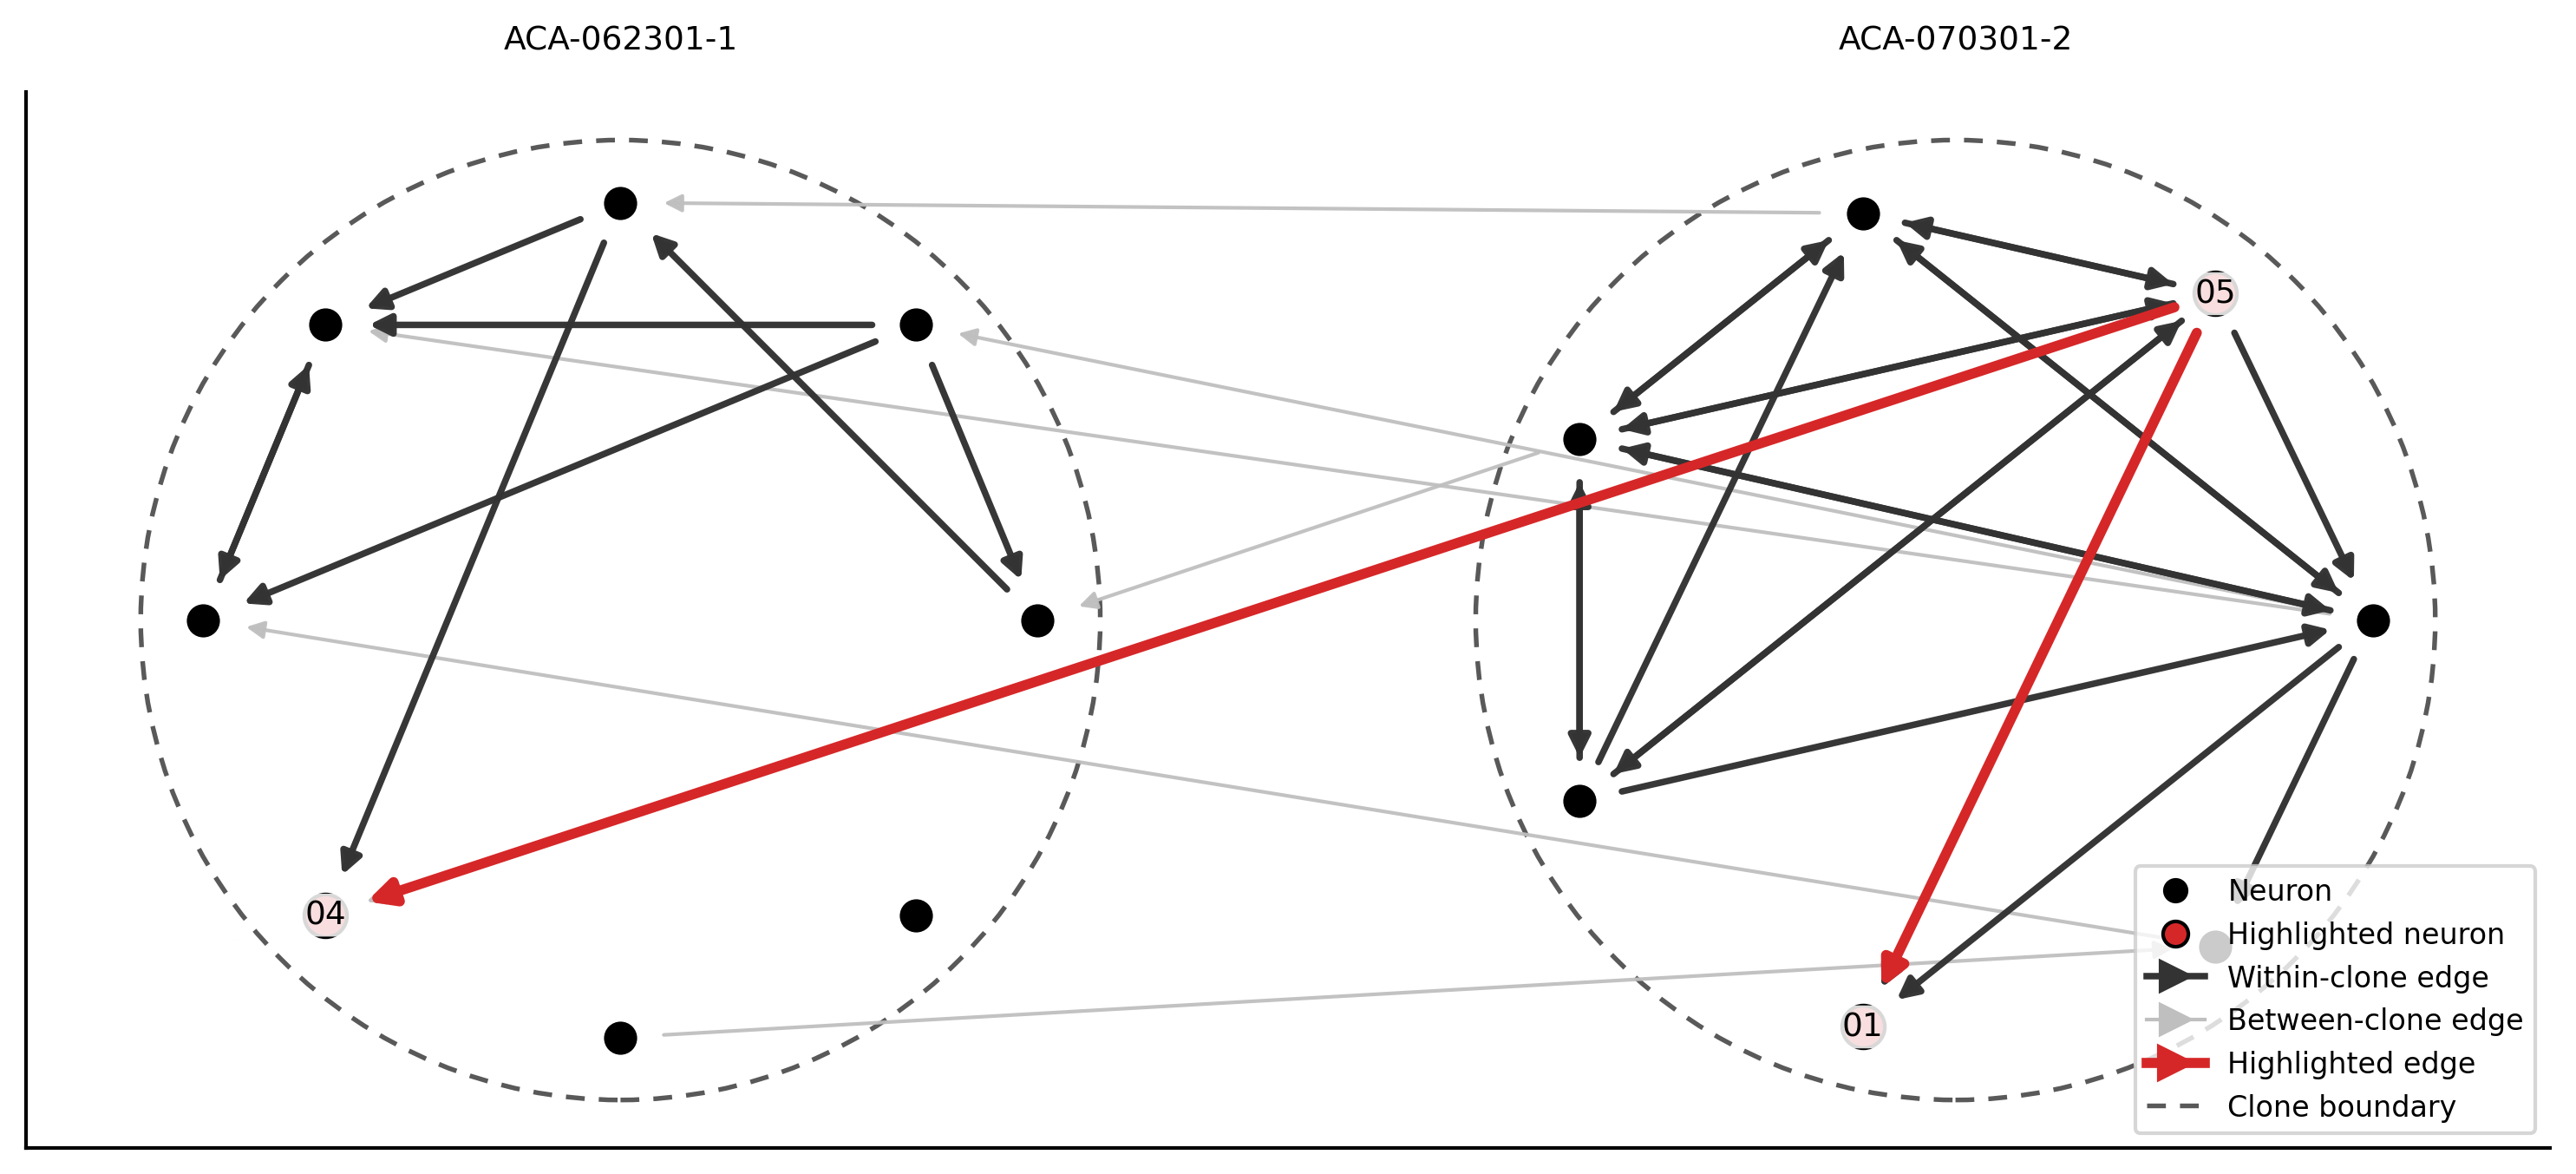

✅ Saved: example_two_clones_ACA-062301-1_vs_ACA-070301-2_highlight.png


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# ===== 5) 画两个 clone：节点标注 + 虚线框；clone内边深、clone间边浅
#          + 高亮指定 neuron（按末尾两位编号）+ 高亮它们之间的边
# ============================================================

cloneA = "ACA-062301-1"
cloneB = "ACA-070301-2"

# --- 你要高亮的“编号”（默认= neuron id 末尾两位）---
hiA = {"04"}          # cloneA 里高亮 04
hiB = {"01", "05"}    # cloneB 里高亮 01,05

# 高亮样式
col_hi_edge = "#D62728"
col_hi_node = "#D62728"

# --- 取两个 clone 的节点 ---
subA = df2[df2["clone"] == cloneA]
subB = df2[df2["clone"] == cloneB]
if subA.empty: raise ValueError(f"CSV 里找不到 clone={cloneA}")
if subB.empty: raise ValueError(f"CSV 里找不到 clone={cloneB}")

idsA = subA[neuron_id_col].astype(str).tolist()
idsB = subB[neuron_id_col].astype(str).tolist()

idxA = sorted(set([name_to_idx[nid] for nid in idsA if nid in name_to_idx]))
idxB = sorted(set([name_to_idx[nid] for nid in idsB if nid in name_to_idx]))
if len(idxA) < 2: raise ValueError(f"cloneA={cloneA} 对应到 sc 的节点数 < 2")
if len(idxB) < 2: raise ValueError(f"cloneB={cloneB} 对应到 sc 的节点数 < 2")

nodeA = [names[i] for i in idxA]
nodeB = [names[i] for i in idxB]
layerA = [str(meta_by_name.loc[nid, "Layer"]) if nid in meta_by_name.index else "Unknown" for nid in nodeA]
layerB = [str(meta_by_name.loc[nid, "Layer"]) if nid in meta_by_name.index else "Unknown" for nid in nodeB]

# --- 合并矩阵 ---
idx_all = idxA + idxB
A_all = sc[np.ix_(idx_all, idx_all)]
B_all = (A_all > edge_thr)
np.fill_diagonal(B_all, False)

lenA, lenB = len(nodeA), len(nodeB)

# --- 每个 clone 内按层排序 ---
canonical = ["1", "2_3", "4", "5", "6"]
layer_rank = {L: i for i, L in enumerate(canonical)}
orderA = sorted(range(lenA), key=lambda i: (layer_rank.get(str(layerA[i]), 999), i))
orderB = sorted(range(lenB), key=lambda i: (layer_rank.get(str(layerB[i]), 999), i))

order_all = [i for i in orderA] + [lenA + j for j in orderB]
B_all = B_all[np.ix_(order_all, order_all)]

nodeA = [nodeA[i] for i in orderA]
layerA = [layerA[i] for i in orderA]
nodeB = [nodeB[i] for i in orderB]
layerB = [layerB[i] for i in orderB]

nodes_all = nodeA + nodeB

# ============================================================
# ===== 布局：两个圆环（左 cloneA，右 cloneB）=====
# ============================================================
rad = 1.0
gap = 3.2

thetaA = np.linspace(0, 2*np.pi, lenA, endpoint=False)
thetaB = np.linspace(0, 2*np.pi, lenB, endpoint=False)

posA = np.c_[rad*np.cos(thetaA) - gap/2, rad*np.sin(thetaA)]
posB = np.c_[rad*np.cos(thetaB) + gap/2, rad*np.sin(thetaB)]
pos = np.vstack([posA, posB])

# ============================================================
# ===== 边分类：within vs between（深浅）=====
# ============================================================
within_mask = np.zeros_like(B_all, dtype=bool)
between_mask = np.zeros_like(B_all, dtype=bool)
within_mask[:lenA, :lenA] = True
within_mask[lenA:, lenA:] = True
between_mask[:lenA, lenA:] = True
between_mask[lenA:, :lenA] = True

B_within  = B_all & within_mask
B_between = B_all & between_mask

col_within, col_between = "0.20", "0.75"
lw_within, lw_between = 1.8, 1.0
ms_within, ms_between = 12, 10

# ============================================================
# ===== 编号提取：默认用 neuron id 末尾两位 =====
# ============================================================
def _tail2(x):
    x = str(x)
    import re
    m = re.search(r"(\d{2})\s*$", x)
    return m.group(1) if m else x

tail_all = [_tail2(n) for n in nodes_all]

# 高亮节点索引（在排序后的坐标系里）
hi_idx = set()
for i in range(lenA):          # cloneA 范围
    if tail_all[i] in hiA:
        hi_idx.add(i)
for i in range(lenA, lenA+lenB):  # cloneB 范围
    if tail_all[i] in hiB:
        hi_idx.add(i)

if len(hi_idx) == 0:
    print("⚠️ 没有匹配到任何高亮 neuron（请检查编号是否真是末尾两位）")
else:
    print("✅ 高亮 neuron tail2:", sorted({tail_all[i] for i in hi_idx}))

# 高亮边：两端都在 hi_idx 的有向边（无论 within/between）
hi_edge_mask = np.zeros_like(B_all, dtype=bool)
if hi_idx:
    hi_list = np.array(sorted(hi_idx), dtype=int)
    hi_edge_mask[np.ix_(hi_list, hi_list)] = True
B_hi = B_all & hi_edge_mask

# ============================================================
# ===== 画图 =====
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(10.0, 5.2))

# ---- 虚线框：每个 clone 一个虚线圆 ----
circleA = mpatches.Circle((-gap/2, 0.0), radius=rad*1.15, fill=False,
                          linestyle=(0, (4, 3)), linewidth=1.3, edgecolor="0.35")
circleB = mpatches.Circle((+gap/2, 0.0), radius=rad*1.15, fill=False,
                          linestyle=(0, (4, 3)), linewidth=1.3, edgecolor="0.35")
ax.add_patch(circleA)
ax.add_patch(circleB)

# ---- 先画浅色 between（普通边）----
src, dst = np.where(B_between)
for i, j in zip(src.tolist(), dst.tolist()):
    x1, y1 = pos[i]
    x2, y2 = pos[j]
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color=col_between, lw=lw_between,
                        shrinkA=12, shrinkB=12, mutation_scale=ms_between, alpha=0.95)
    )

# ---- 再画深色 within（普通边）----
src, dst = np.where(B_within)
for i, j in zip(src.tolist(), dst.tolist()):
    x1, y1 = pos[i]
    x2, y2 = pos[j]
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color=col_within, lw=lw_within,
                        shrinkA=12, shrinkB=12, mutation_scale=ms_within, alpha=0.98)
    )

# ---- 最后画高亮边（覆盖在最上面）----
src, dst = np.where(B_hi)
for i, j in zip(src.tolist(), dst.tolist()):
    x1, y1 = pos[i]
    x2, y2 = pos[j]
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color=col_hi_edge, lw=2.8,
                        shrinkA=12, shrinkB=12, mutation_scale=14, alpha=1.0)
    )

# ---- 节点（全黑）----
ax.scatter(pos[:, 0], pos[:, 1], s=70, c="black", edgecolors="black", linewidths=0.8, zorder=3)

# ---- 高亮节点（覆盖在上面）----
if hi_idx:
    hi_idx_sorted = np.array(sorted(hi_idx), dtype=int)
    ax.scatter(pos[hi_idx_sorted, 0], pos[hi_idx_sorted, 1],
               s=140, c=col_hi_node, edgecolors="black", linewidths=1.0, zorder=4)

    # 只给高亮节点打标签（显示 01/04/05）
    for i in hi_idx_sorted:
        x, y = pos[i]
        ax.text(x, y, tail_all[i], fontsize=9, color="black", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
                zorder=5)

# ---- clone 名称 ----
ax.text(-gap/2, rad*1.35, f"{cloneA}", ha="center", va="bottom", fontsize=9)
ax.text(+gap/2, rad*1.35, f"{cloneB}", ha="center", va="bottom", fontsize=9)

# ---- legend ----
h_within  = plt.Line2D([0, 1], [0, 0], color=col_within,  lw=lw_within,  marker=">", markersize=8, markevery=[1], label="Within-clone edge")
h_between = plt.Line2D([0, 1], [0, 0], color=col_between, lw=lw_between, marker=">", markersize=8, markevery=[1], label="Between-clone edge")
h_hi      = plt.Line2D([0, 1], [0, 0], color=col_hi_edge, lw=2.8, marker=">", markersize=9, markevery=[1], label="Highlighted edge")
h_node    = plt.Line2D([0],[0], marker="o", linestyle="None", markerfacecolor="black", markeredgecolor="black", markersize=6, label="Neuron")
h_hinode  = plt.Line2D([0],[0], marker="o", linestyle="None", markerfacecolor=col_hi_node, markeredgecolor="black", markersize=7, label="Highlighted neuron")
h_box     = plt.Line2D([0, 1], [0, 0], color="0.35", lw=1.3, linestyle=(0, (4, 3)), label="Clone boundary")
ax.legend(handles=[h_node, h_hinode, h_within, h_between, h_hi, h_box],
          loc="lower right", fontsize=8, frameon=True)

# ---- 美化 ----
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig(f"example_two_clones_{cloneA}_vs_{cloneB}_highlight.svg", dpi=300, format="svg", bbox_inches="tight")
plt.show()

print(f"✅ Saved: example_two_clones_{cloneA}_vs_{cloneB}_highlight.png")

[CHECK] clone=MOs-233374-4 | group=MOs | n=6 | p=0.167 | LCC=5


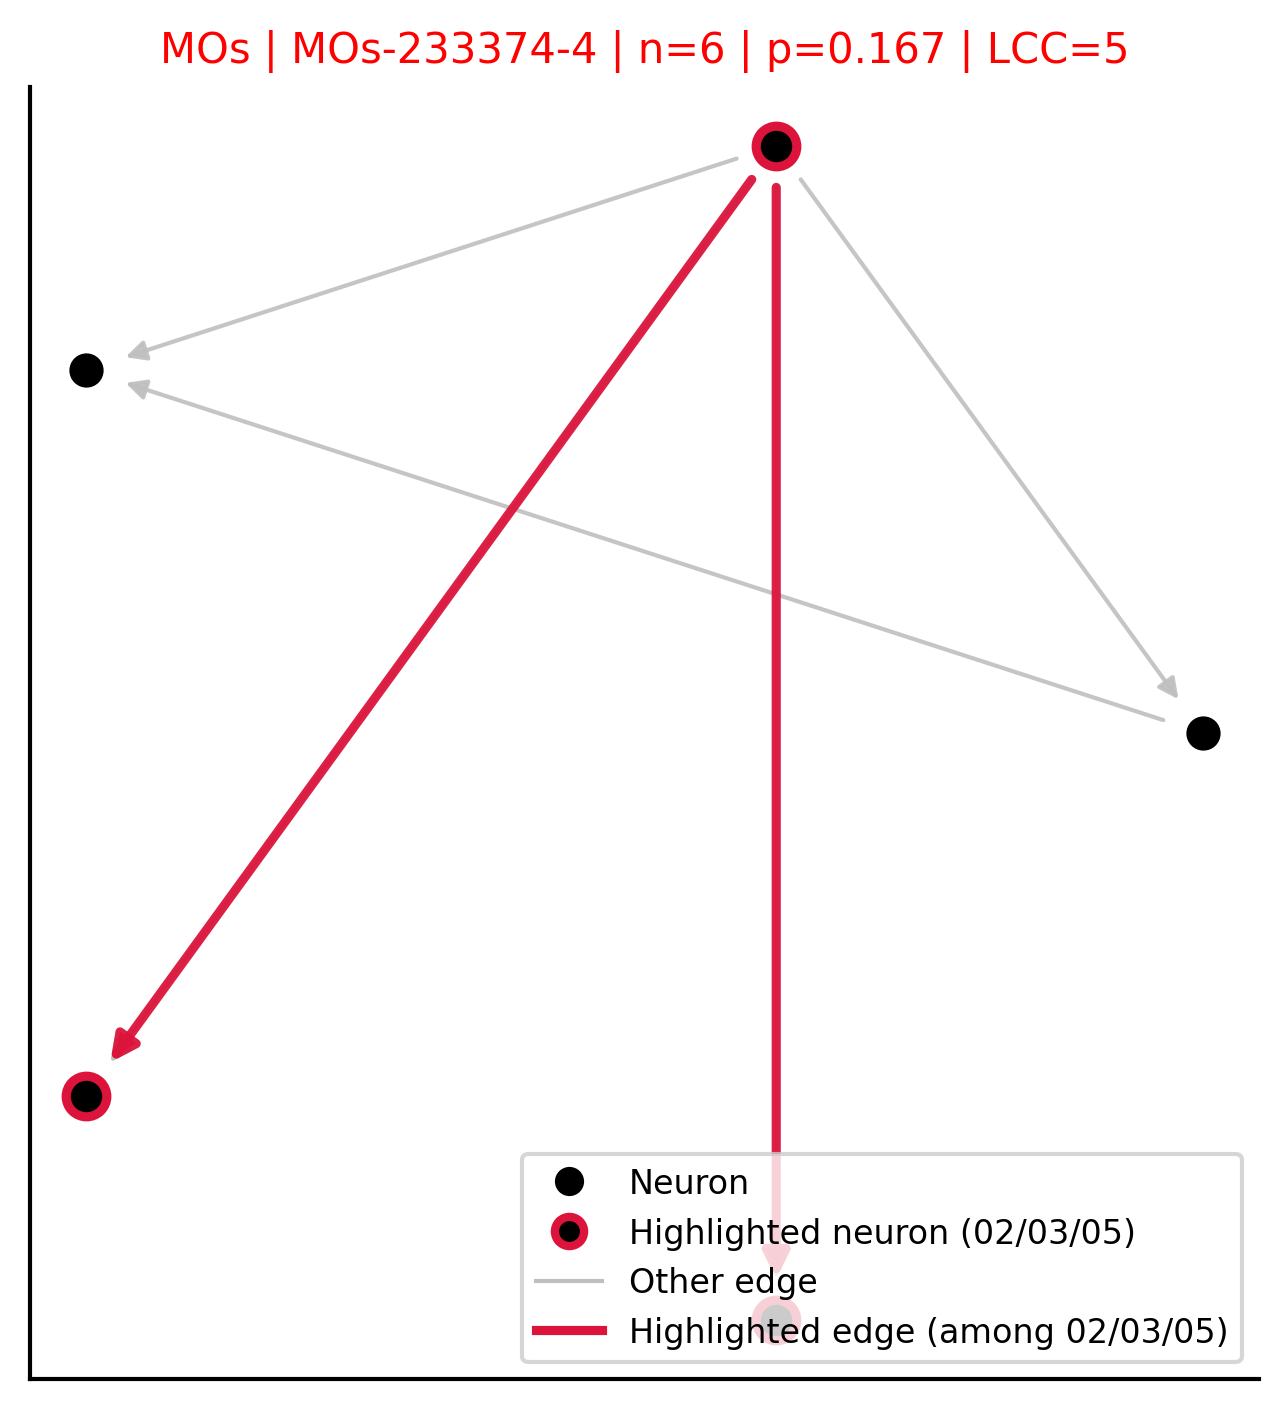

✅ Saved: example_clone_MOs-233374-4_topology.svg


In [38]:
import re
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ===== 5) 画一个示例 clone 的拓扑图 + legend，并检查指定 clone =====
# ============================================================

# 你要看的示例 clone（也可以改成别的）
example_clone = "MOs-233374-4"

# --- 取这个 clone 的子图 ---
sub = df2[df2["clone"] == example_clone]
if sub.empty:
    raise ValueError(f"CSV 里找不到 clone={example_clone}")

node_ids = sub[neuron_id_col].astype(str).tolist()
idxs = sorted(set([name_to_idx[nid] for nid in node_ids if nid in name_to_idx]))
if len(idxs) < 2:
    raise ValueError(f"clone={example_clone} 对应到 sc 的节点数 < 2，无法画图")

node_ids2 = [names[i] for i in idxs]
layers2 = [str(meta_by_name.loc[nid, "Layer"]) if nid in meta_by_name.index else "Unknown" for nid in node_ids2]
A_sub = sc[np.ix_(idxs, idxs)]

# --- 计算 p 和 LCC（逻辑与你上面完全一致）---
B = (A_sub > edge_thr); np.fill_diagonal(B, False)
n = B.shape[0]
e = int(B.sum())
p = e / (n * (n - 1)) if n > 1 else 0.0

U = B | B.T
visited = np.zeros(n, dtype=bool)
lcc = 0
for s in range(n):
    if visited[s]:
        continue
    stack = [s]; visited[s] = True; cnt = 0
    while stack:
        v = stack.pop(); cnt += 1
        for u in np.flatnonzero(U[v]):
            if not visited[u]:
                visited[u] = True
                stack.append(u)
    if cnt > lcc:
        lcc = cnt

# --- 判定它属于哪个 group（按你 clone->group 投票结果）---
belongs_group = clone_to_group.get(example_clone, "Unknown")
print(f"[CHECK] clone={example_clone} | group={belongs_group} | n={n} | p={p:.3f} | LCC={lcc}")

# ============================================================
# ===== 画图：按你的要求（层间排序；全黑；去掉layer6；高亮02/03/05及其之间的边）=====
# ============================================================

# 1) 去掉 layer=6 的神经元
keep = np.array([str(L) != "6" for L in layers2], dtype=bool)
if keep.sum() < 2:
    raise ValueError("去掉 layer=6 后节点数 < 2，无法画图")

node_ids_f = [nid for nid, k in zip(node_ids2, keep) if k]
layers_f   = [L   for L,   k in zip(layers2,  keep) if k]
A_f = A_sub[np.ix_(keep, keep)]
B_f = (A_f > edge_thr)
np.fill_diagonal(B_f, False)

# 2) 高亮 02/03/05：用“ID末尾两位数字”匹配（更鲁棒）
def _tail2(x):
    x = str(x)
    m = re.search(r"(\d{2})\s*$", x)
    return m.group(1) if m else None

highlight_tail = {"02", "03", "05"}

# 3) 层间排序：先按 layer 顺序重排节点，再画
canonical = ["1", "2_3", "4", "5", "6"]  # 你要的层顺序（layer6已删，这里保留也没事）
layer_rank = {L: i for i, L in enumerate(canonical)}

order = sorted(
    range(len(node_ids_f)),
    key=lambda i: (layer_rank.get(str(layers_f[i]), 999), i)  # 未知层放最后；同层内保序
)

node_ids_f = [node_ids_f[i] for i in order]
layers_f   = [layers_f[i]   for i in order]
A_f        = A_f[np.ix_(order, order)]
B_f        = (A_f > edge_thr)
np.fill_diagonal(B_f, False)

tails = [_tail2(nid) for nid in node_ids_f]
hl = np.array([(t in highlight_tail) for t in tails], dtype=bool)

# 如果你发现匹配不到（hl全False），把下面这行打开看看末尾两位是什么：
# print(list(zip(node_ids_f, tails)))

# 4) 布局：圆环（现在顺序已经是“按层分段”的）
N = len(node_ids_f)
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
pos = np.c_[np.cos(theta), np.sin(theta)]

# 5) 画边：先灰色所有边，再红色覆盖 hl-hl 的边
fig, ax = plt.subplots(1, 1, figsize=(6.8, 4.8))

edge_color_other = "0.75"
edge_lw_other = 1.0
edge_color_hl = "crimson"
edge_lw_hl = 2.2

src, dst = np.where(B_f)
for i, j in zip(src.tolist(), dst.tolist()):
    x1, y1 = pos[i]
    x2, y2 = pos[j]
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-|>",
            color=edge_color_other, lw=edge_lw_other,
            shrinkA=10, shrinkB=10,
            mutation_scale=10, alpha=0.9
        )
    )

src_h, dst_h = np.where(B_f & hl[:, None] & hl[None, :])
for i, j in zip(src_h.tolist(), dst_h.tolist()):
    x1, y1 = pos[i]
    x2, y2 = pos[j]
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-|>",
            color=edge_color_hl, lw=edge_lw_hl,
            shrinkA=10, shrinkB=10,
            mutation_scale=12, alpha=0.95
        )
    )

# 6) 画点：所有 neuron 黑色；高亮点=黑色填充+红色描边+更大
node_size = 55
node_size_hl = 95

ax.scatter(pos[~hl, 0], pos[~hl, 1],
           s=node_size, c="black", edgecolors="black", linewidths=0.8, zorder=3)

ax.scatter(pos[hl, 0], pos[hl, 1],
           s=node_size_hl, c="black", edgecolors=edge_color_hl, linewidths=2.2, zorder=4)

# 7) legend：不带序号；不显示 layer；只说明 neuron/高亮/边
h_neuron = plt.Line2D([0],[0], marker="o", linestyle="None",
                      markerfacecolor="black", markeredgecolor="black",
                      markersize=6, label="Neuron")

h_neuron_hl = plt.Line2D([0],[0], marker="o", linestyle="None",
                         markerfacecolor="black", markeredgecolor=edge_color_hl,
                         markeredgewidth=2.0, markersize=7,
                         label="Highlighted neuron (02/03/05)")

h_edge = plt.Line2D([0,1],[0,0], color=edge_color_other, lw=edge_lw_other, label="Other edge")
h_edge_hl = plt.Line2D([0,1],[0,0], color=edge_color_hl, lw=edge_lw_hl, label="Highlighted edge (among 02/03/05)")

ax.legend(handles=[h_neuron, h_neuron_hl, h_edge, h_edge_hl],
          loc="lower right", fontsize=8, frameon=True)

# 8) 美化：只保留左/下轴；去坐标刻度
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect("equal", adjustable="box")

tcolor = "red" if lcc < 6 else "black"
ax.set_title(f"{belongs_group} | {example_clone} | n={n} | p={p:.3f} | LCC={lcc}", fontsize=10, color=tcolor)

plt.tight_layout()
plt.savefig(f"example_clone_{example_clone}_topology.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Saved: example_clone_{example_clone}_topology.svg")

[CHECK] clone=MOs-221021-1 | group=MOs | n=7 | p=0.143 | LCC=5
⚠️ clone MOs-221021-1 不属于 MOp（按 Clone_region 投票结果是 MOs）


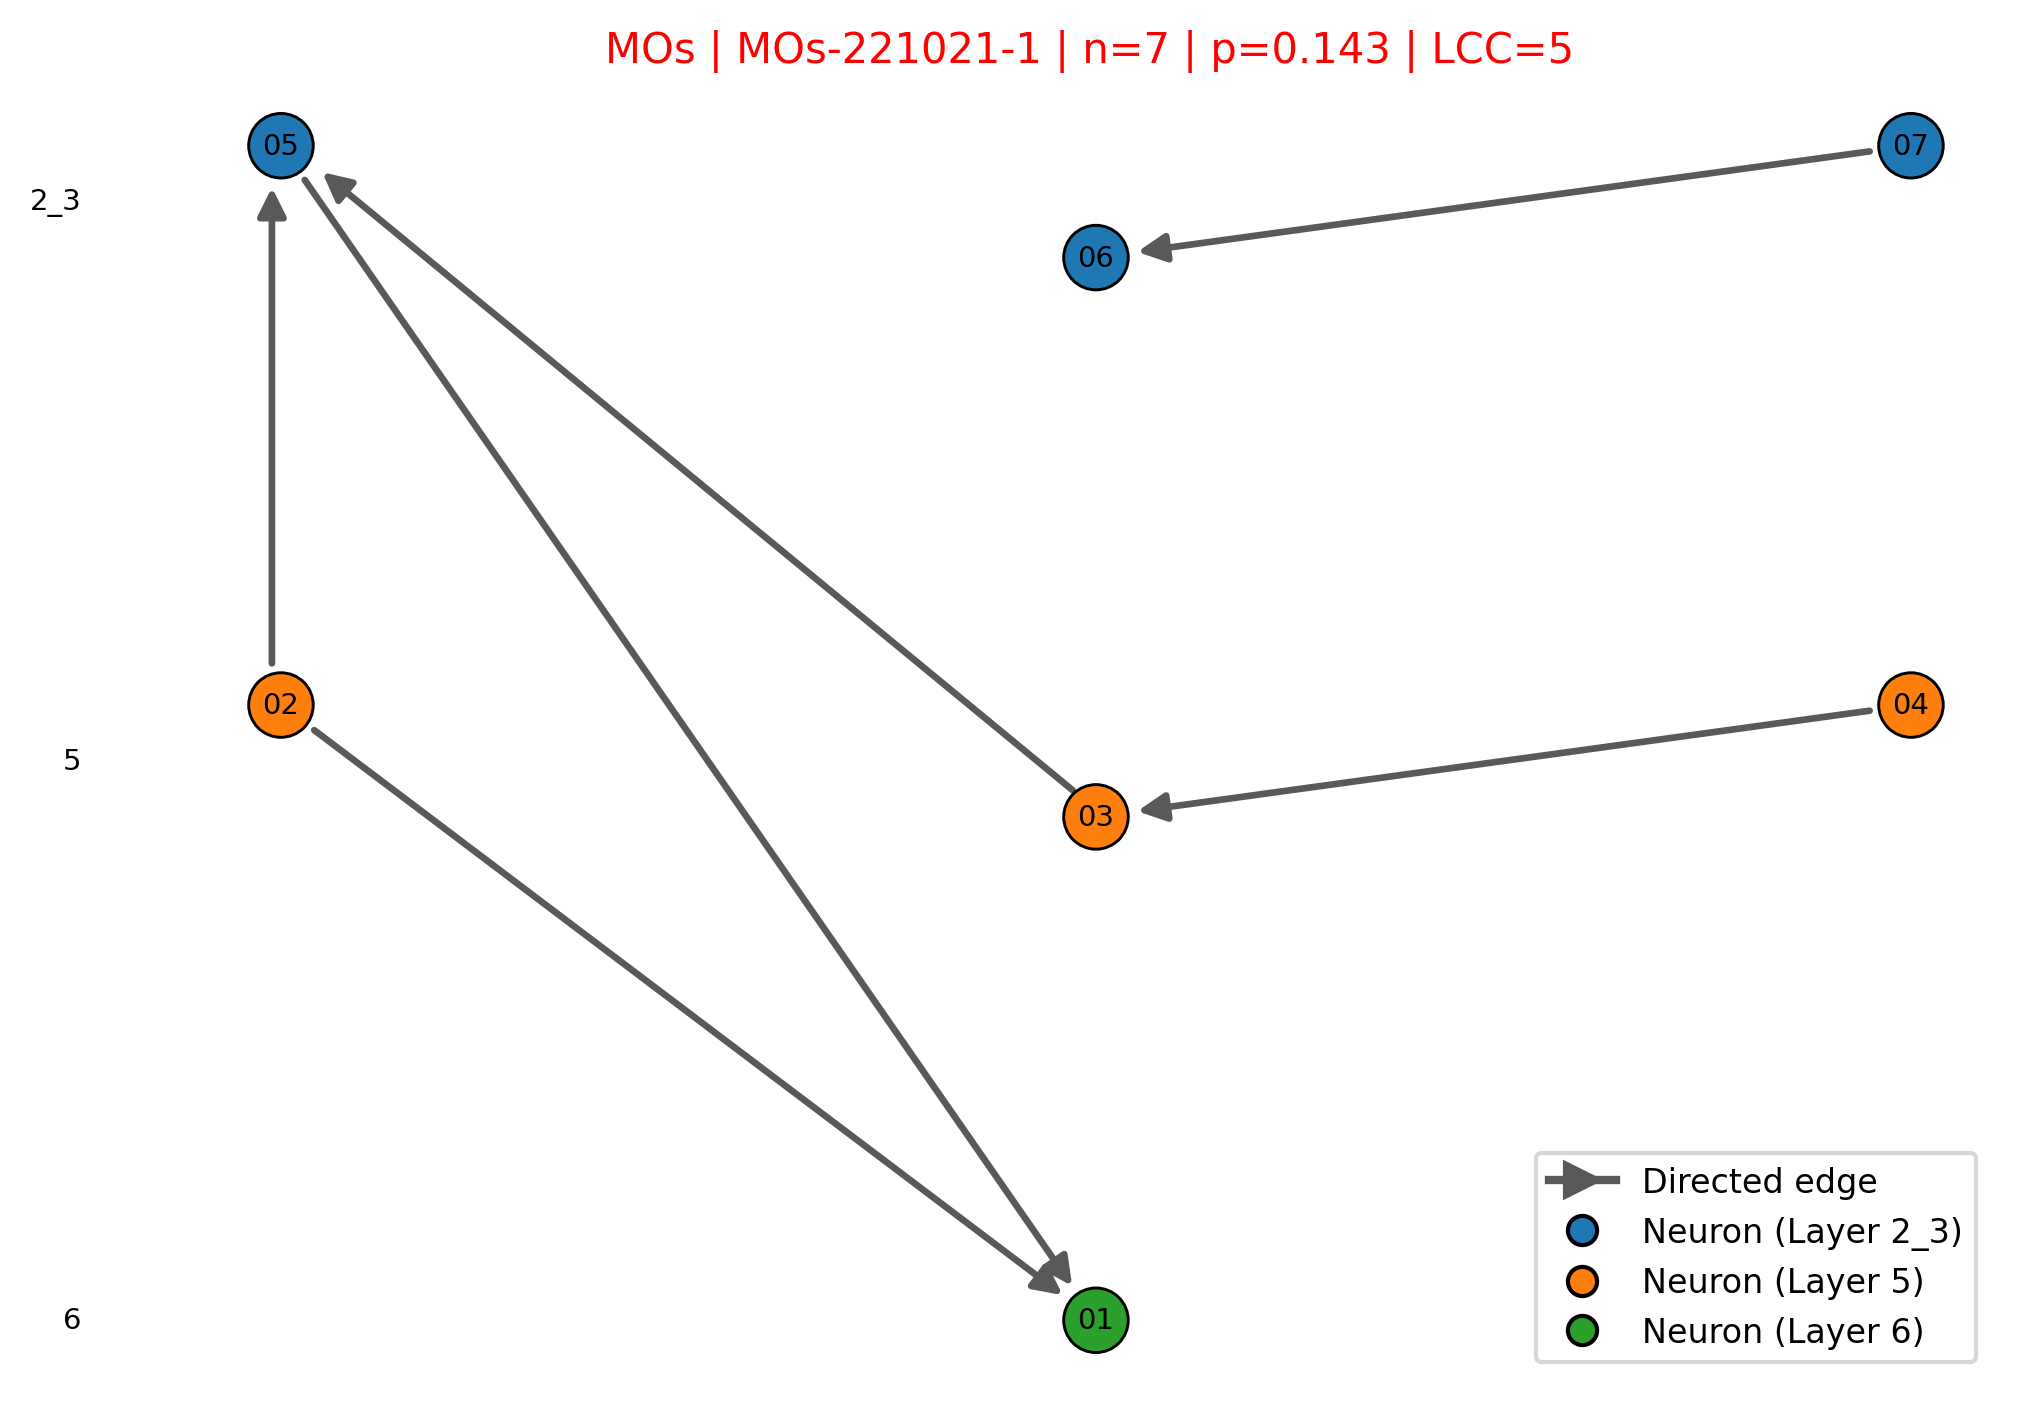

✅ Saved: example_clone_MOs-221021-1_topology.png


In [26]:
# ============================================================
# ===== 5) 画一个示例 clone 的拓扑图 + legend，并检查指定 clone =====
# ============================================================

# 你要看的示例 clone（也可以改成别的）
example_clone = "MOs-221021-1"

# --- 取这个 clone 的子图 ---
sub = df2[df2["clone"] == example_clone]
if sub.empty: raise ValueError(f"CSV 里找不到 clone={example_clone}")

node_ids = sub[neuron_id_col].astype(str).tolist()
idxs = sorted(set([name_to_idx[nid] for nid in node_ids if nid in name_to_idx]))
if len(idxs) < 2: raise ValueError(f"clone={example_clone} 对应到 sc 的节点数 < 2，无法画图")

node_ids2 = [names[i] for i in idxs]
layers2 = [str(meta_by_name.loc[nid, "Layer"]) if nid in meta_by_name.index else "Unknown" for nid in node_ids2]
A_sub = sc[np.ix_(idxs, idxs)]

# --- 计算 p 和 LCC（逻辑与你上面完全一致）---
B = (A_sub > edge_thr); np.fill_diagonal(B, False)
n = B.shape[0]; e = int(B.sum()); p = e / (n * (n - 1)) if n > 1 else 0.0

U = B | B.T
visited = np.zeros(n, dtype=bool)
lcc = 0
for s in range(n):
    if visited[s]: continue
    stack = [s]; visited[s] = True; cnt = 0
    while stack:
        v = stack.pop(); cnt += 1
        for u in np.flatnonzero(U[v]):
            if not visited[u]: visited[u] = True; stack.append(u)
    if cnt > lcc: lcc = cnt

# --- 判定它是否属于 MOp 组（按你 clone->group 投票结果）---
belongs_group = clone_to_group.get(example_clone, "Unknown")
print(f"[CHECK] clone={example_clone} | group={belongs_group} | n={n} | p={p:.3f} | LCC={lcc}")
if belongs_group == "MOp" and lcc < 6:
    print(f"✅ MOp 中 clone {example_clone} 的最大弱连通分量 LCC={lcc} < 6（你要找的那个）")
elif belongs_group == "MOp":
    print(f"⚠️ clone {example_clone} 属于 MOp，但 LCC={lcc} >= 6")
else:
    print(f"⚠️ clone {example_clone} 不属于 MOp（按 Clone_region 投票结果是 {belongs_group}）")

# --- 画示例图 + legend（右下角；layer=Neuron；边只保留一个有向连接示意）---
fig, ax = plt.subplots(1, 1, figsize=(6.8, 4.8))
draw_clone_on_ax(ax, A_sub, node_ids2, layers2, edge_thr=edge_thr)

# 复刻你 draw_clone_on_ax 里的 layer 顺序和配色（只用于 legend，不改画法）
canonical = ["1", "2_3", "4", "5", "6"]
present = [str(x) for x in layers2]
layer_order = [L for L in canonical if L in present] + [L for L in present if L not in canonical]
layer_order = list(dict.fromkeys(layer_order))
base_colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#7f7f7f","#bcbd22"]
layer_to_color = {L: base_colors[i % len(base_colors)] for i, L in enumerate(layer_order)}

# legend：layer（按你的要求写成“Neuron”）
handles_layer = [plt.Line2D([0],[0], marker="o", linestyle="None", markerfacecolor=layer_to_color[L], markeredgecolor="black", markersize=7, label=f"Neuron (Layer {L})") for L in layer_order]

# legend：只保留一个“带箭头”的有向连接示意（不区分单/双向，不给 edge 的 legend）
h_dir = plt.Line2D([0, 1], [0, 0], color="0.35", linewidth=2.0, marker=">", markersize=8, markevery=[1], label="Directed edge")

ax.legend(handles=[h_dir] + handles_layer, loc="lower right", fontsize=8, frameon=True)

tcolor = "red" if lcc < 6 else "black"
ax.set_title(f"{belongs_group} | {example_clone} | n={n} | p={p:.3f} | LCC={lcc}", fontsize=10, color=tcolor)

plt.tight_layout()
plt.savefig(f"example_clone_{example_clone}_topology.png", dpi=300)
plt.show()

print(f"✅ Saved: example_clone_{example_clone}_topology.png")

In [1]:
import numpy as np
import pandas as pd
import torch

# ================= triad motif 计数器（13 motifs）=================
class motifRegular:
    def __init__(self, numOfNeuron: int, device="cpu"):
        self.device = torch.device(device) if isinstance(device, str) else device
        n = numOfNeuron
        self.L = torch.ones((1, n), device=self.device)
        self.P = torch.ones((n, n), device=self.device)
        self.P.fill_diagonal_(0)

    def cal(self, a: torch.Tensor) -> torch.Tensor:
        w = (a > 0).to(a.dtype) * self.P
        pmw = self.P - w

        w0 = pmw * pmw.T
        w1 = w   * pmw.T
        w2 = pmw * w.T
        w3 = w   * w.T

        q = torch.zeros(14, dtype=torch.float32, device=self.device)

        q[1]  = 0.5 * self.L @ (w1 * (w1 @ w0)) @ self.L.T
        q[2]  = 0.5 * self.L @ (w0 * (w1 @ w2)) @ self.L.T
        q[3]  =       self.L @ (w1 * (w0 @ w2)) @ self.L.T
        q[4]  =       self.L @ (w1 * (w1 @ w2)) @ self.L.T

        q[5]  =       self.L @ (w3 * (w1 @ w0)) @ self.L.T
        q[6]  =       self.L @ (w3 * (w2 @ w0)) @ self.L.T
        q[7]  = 0.5 * self.L @ (w3 * (w1 @ w2)) @ self.L.T
        q[8]  = 0.5 * self.L @ (w3 * (w2 @ w1)) @ self.L.T

        q[9]  = 0.5 * self.L @ (w3 * (w3 @ w0)) @ self.L.T
        q[10] = (1.0/3.0) * self.L @ (w1 * (w2 @ w2)) @ self.L.T
        q[11] =       self.L @ (w3 * (w2 @ w2)) @ self.L.T
        q[12] =       self.L @ (w3 * (w3 @ w2)) @ self.L.T
        q[13] = (1.0/6.0) * self.L @ (w3 * (w3 @ w3)) @ self.L.T

        return q[1:14]  # (13,)

def c_n_3(n: int) -> int:
    return 0 if n < 3 else (n * (n - 1) * (n - 2)) // 6

def real_motif_for_submatrix(A, threshold=0.0, device="cpu"):
    A = np.asarray(A, dtype=float)
    np.fill_diagonal(A, 0.0)

    edge = (A > threshold)
    np.fill_diagonal(edge, False)

    n = A.shape[0]
    e = int(edge.sum())
    if n < 3 or e == 0:
        return None

    mr = motifRegular(n, device=device)
    real = mr.cal(torch.from_numpy(edge.astype(np.float32)).to(mr.device)).cpu().numpy()
    return {"real": real, "n": n, "e": e}

# ================= 主流程：按 clone 计算 + 汇总（改成：最大连通子图）=================
sc_path    = "wb_alltype_sc_subset_zj_1_2.5_42_1209.npy"
names_path = "wb_alltype_sc_subset_names_zj_1_2.5_42_1209.npy"
csv_path   = "Metadata_PFC_MOp.csv"

sc = np.load(sc_path)
names = np.load(names_path, allow_pickle=True)
names = names.tolist() if isinstance(names, np.ndarray) else list(names)
names = np.asarray([str(x) for x in names], dtype=str)

df = pd.read_csv(csv_path)

if "name" in df.columns:
    id_col = "name"
elif "Unnamed: 0" in df.columns:
    id_col = "Unnamed: 0"
else:
    raise ValueError("CSV 里找不到 neuron id 列（尝试 'name' / 'Unnamed: 0'）。")

need_cols = {"clone", "Layer", "Clone_region"}
miss = need_cols - set(df.columns)
if miss:
    raise ValueError(f"CSV 缺少列: {miss}")

meta = df.set_index(id_col)
clone_arr  = meta.reindex(names)["clone"].to_numpy()
layer_arr  = meta.reindex(names)["Layer"].astype(str).to_numpy()
region_arr = meta.reindex(names)["Clone_region"].astype(str).to_numpy()

valid = ~pd.isna(clone_arr)
print(f"总节点数: {len(names)}")
print(f"按 clone 成功匹配到的节点数: {int(valid.sum())}")
print(f"共有 {pd.unique(clone_arr[valid]).size} 个 clone")

layer_order  = ["2_3", "5", "6"]
motif_labels = [f"Motif {i+1}" for i in range(13)]
device, thr  = "cpu", 0.0

records = []

for cl in pd.unique(clone_arr[valid]):
    idxs = np.flatnonzero((clone_arr == cl) & valid)
    if idxs.size < 3:
        continue

    # ---- clone 原始子图 ----
    A_sub = sc[np.ix_(idxs, idxs)]
    B = (A_sub > thr)
    np.fill_diagonal(B, False)

    # ---- 找最大“弱连通”分量（把有向当无向）----
    U = B | B.T
    n0 = U.shape[0]
    if n0 < 3:
        continue
    visited = np.zeros(n0, dtype=bool)
    best_nodes = []
    for s in range(n0):
        if visited[s]:
            continue
        stack = [s]
        visited[s] = True
        comp = []
        while stack:
            v = stack.pop()
            comp.append(v)
            for u in np.flatnonzero(U[v]):
                if not visited[u]:
                    visited[u] = True
                    stack.append(u)
        if len(comp) > len(best_nodes):
            best_nodes = comp

    if len(best_nodes) < 3:
        continue

    best_nodes = np.asarray(best_nodes, dtype=int)

    # ---- 最大连通子图 ----
    A_lcc = A_sub[np.ix_(best_nodes, best_nodes)]
    res = real_motif_for_submatrix(A_lcc, threshold=thr, device=device)
    if res is None:
        continue

    n, e = res["n"], res["e"]
    sparsity = e / (n * (n - 1)) if n > 1 else np.nan

    row = {"clone": cl, "n": n, "e": e, "sparsity": sparsity, "c_n^3": c_n_3(n)}

    # ---- region：仍然用 clone 内第一个有效 Clone_region（不改变你原逻辑）----
    regs = region_arr[idxs]
    regs = regs[(regs != "nan") & (regs != "None") & (regs != "")]
    row["region"] = regs[0] if regs.size else ""

    # ---- 13 motifs：最大连通子图的 real ----
    for k, m in enumerate(motif_labels):
        row[f"real_{m}"] = float(res["real"][k])

    # ---- layer 内出入度：只算最大连通子图内部 ----
    A_bin = (A_lcc > thr).astype(np.uint8)
    np.fill_diagonal(A_bin, 0)
    out_deg = A_bin.sum(1)
    in_deg  = A_bin.sum(0)

    layers = layer_arr[idxs][best_nodes]
    for L in layer_order:
        msk = (layers == L)
        nL = int(msk.sum())
        row[f"layer_{L}_n_nodes"]  = nL
        row[f"layer_{L}_out_sum"]  = int(out_deg[msk].sum()) if nL else 0
        row[f"layer_{L}_in_sum"]   = int(in_deg[msk].sum())  if nL else 0
        row[f"layer_{L}_out_mean"] = float(out_deg[msk].mean()) if nL else 0.0
        row[f"layer_{L}_in_mean"]  = float(in_deg[msk].mean())  if nL else 0.0

    records.append(row)

all_stats_df = pd.DataFrame.from_records(records)
print("\n=== clone 最大连通子图统计（前几行） ===")
print(all_stats_df.head())

# ================= 统计：PFC / MOp / MOs（仍是按 clone 的 region 映射）=================
def map_region_to_group(r):
    if r is None:
        return np.nan
    r = str(r).strip()
    if r == "" or r.lower() == "nan":
        return np.nan
    if r.startswith(("ACA", "PL", "FRP", "ORB")):
        return "PFC"
    if r.startswith("MOp"):
        return "MOp"
    if r.startswith("MOs"):
        return "MOs"
    return np.nan

all_stats_df["group"] = all_stats_df["region"].map(map_region_to_group)
df3 = all_stats_df[all_stats_df["group"].isin(["PFC", "MOp", "MOs"])].copy()

# ---- real_motif / cn3 ----
motif_cols = [f"real_Motif {i+1}" for i in range(13)]
for c in motif_cols:
    df3[f"{c}_per_cn3"] = df3[c] / df3["c_n^3"].replace(0, np.nan)

ratio_cols = [f"{c}_per_cn3" for c in motif_cols]
motif_stats = df3.groupby("group")[ratio_cols].agg(["mean", "var"])
motif_stats.columns = [f"{a}_{b}" for a, b in motif_stats.columns]

print("\n=== 各组（最大连通子图）real_motif/cn3：均值 & 方差 ===")
print(motif_stats)

# ---- layer 平均出入度（最大连通子图）----
deg_cols = []
for L in layer_order:
    deg_cols += [f"layer_{L}_out_mean", f"layer_{L}_in_mean"]

deg_stats = df3.groupby("group")[deg_cols].agg(["mean", "var"])
deg_stats.columns = [f"{a}_{b}" for a, b in deg_stats.columns]

print("\n=== 各组（最大连通子图）layer 平均出入度(out/in mean)：均值 & 方差 ===")
print(deg_stats)

总节点数: 751
按 clone 成功匹配到的节点数: 751
共有 92 个 clone

=== clone 最大连通子图统计（前几行） ===
           clone  n   e  sparsity  c_n^3 region  real_Motif 1  real_Motif 2  \
0   ACA-062301-1  6   8  0.266667     20    ACA           3.0           1.0   
1   ACA-070301-2  7  20  0.476190     35    ACA           1.0           0.0   
2  ACA-071502-03  9  39  0.541667     84    ACA           1.0           1.0   
3   ACA-081201-1  7  26  0.619048     35     PL           0.0           1.0   
4   ACA-230026-1  5   4  0.200000     10    ACA           1.0           1.0   

   real_Motif 3  real_Motif 4  ...  layer_5_n_nodes  layer_5_out_sum  \
0           3.0           0.0  ...                4                4   
1           3.0           1.0  ...                2                0   
2           3.0           1.0  ...                1                1   
3           2.0           2.0  ...                3                9   
4           2.0           0.0  ...                2                1   

   layer_5_in_su

过滤后 clone 行数: 77（只保留 LCC>=6）
group
MOp    35
MOs    29
PFC    13
Name: count, dtype: int64


/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


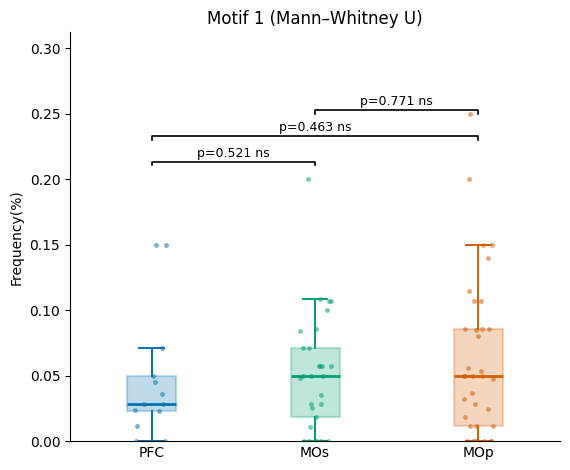

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' sin

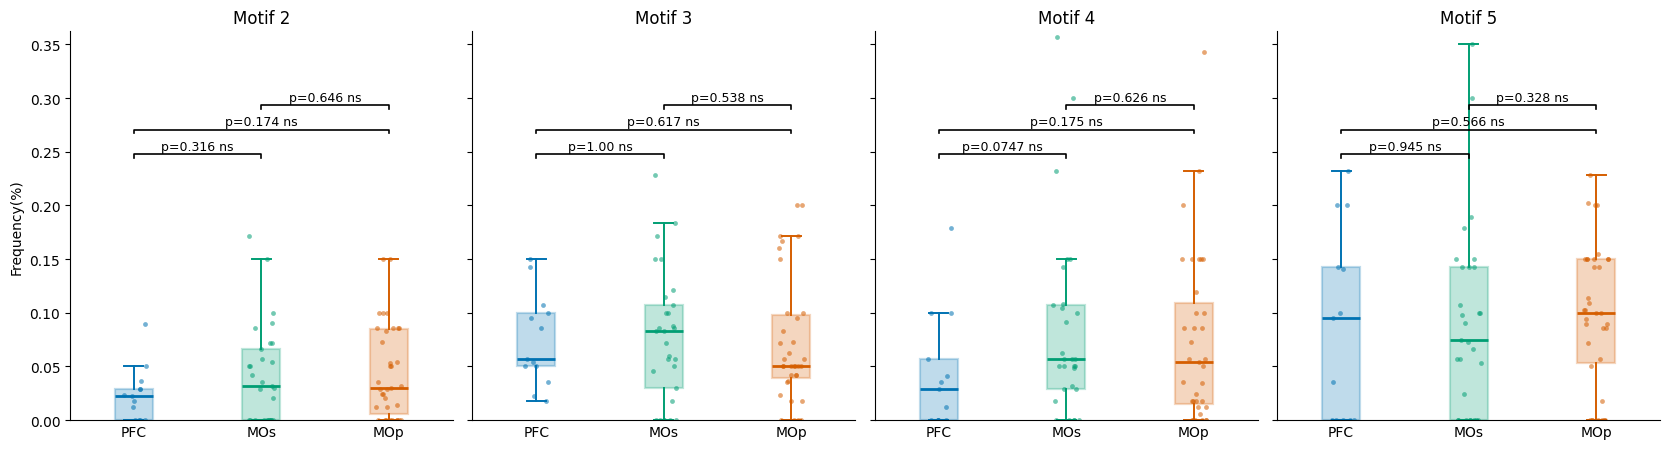

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' sin

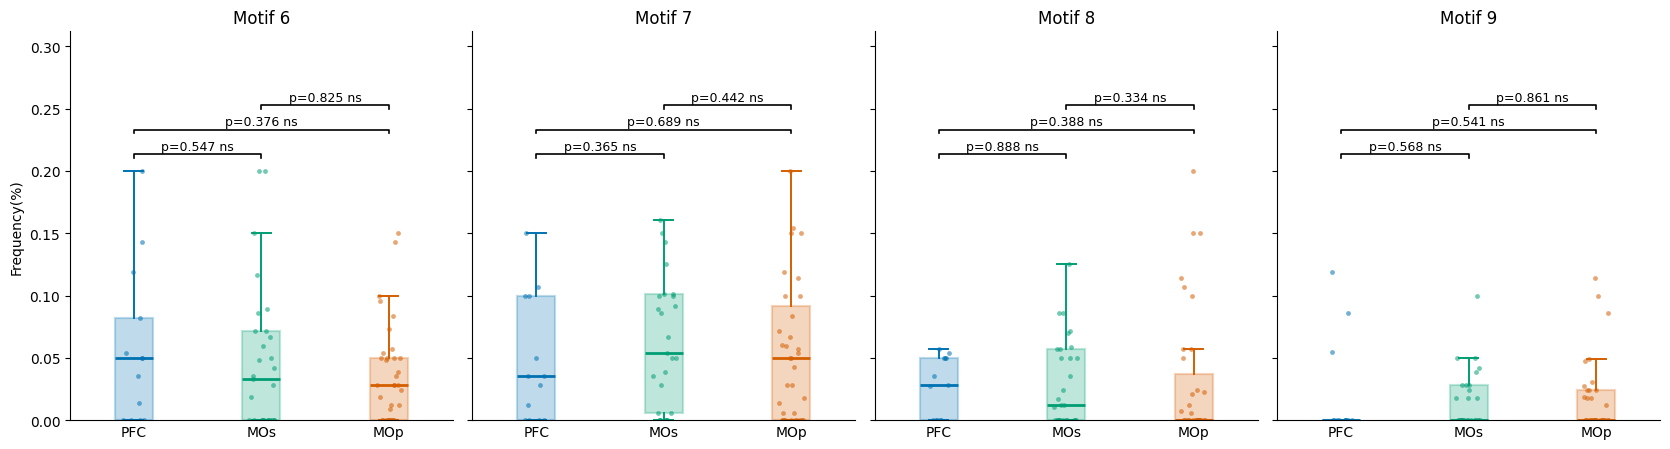

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/2822153073.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' sin

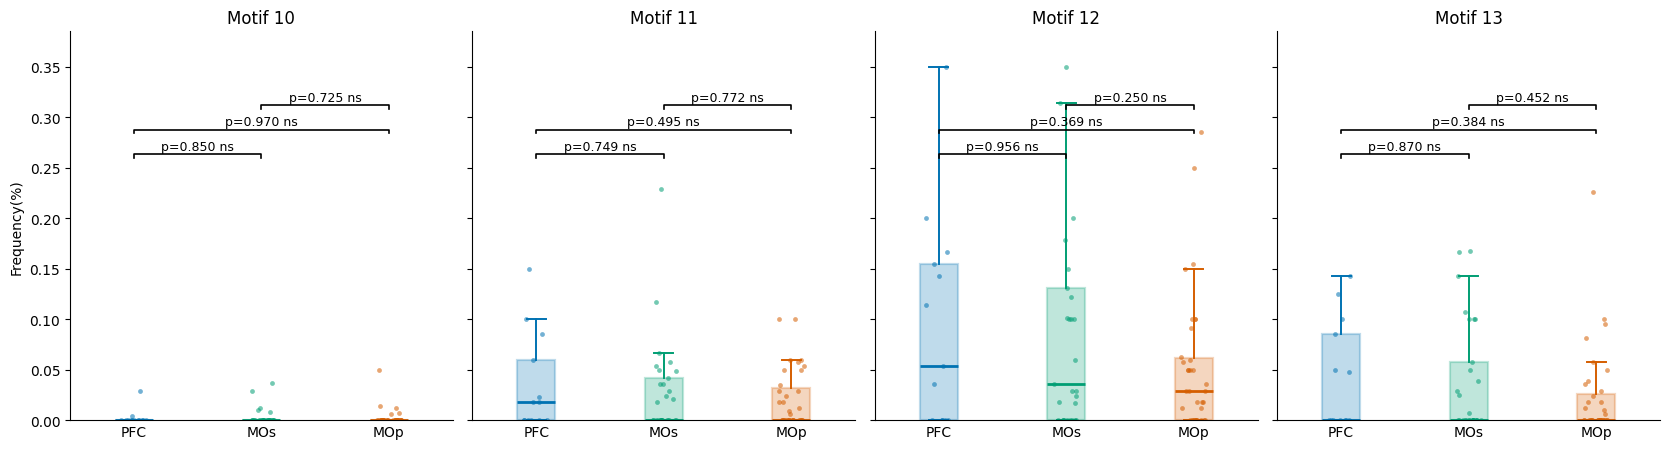

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# ===== 0) 前提：你已有 all_stats_df；并且也有 sc / names / df =====
# ============================================================
edge_thr = 0.0
LCC_MIN  = 6
use_ratio = True  # True: real/cn3；False: 原始 real

# 三个脑区配色（Okabe-Ito）
colors = {"PFC": "#0072B2", "MOp": "#D55E00", "MOs": "#009E73"}

# 顺序改成：PFC -> MOs -> MOp
groups = ["PFC", "MOs", "MOp"]

pairs = [(0, 1), (0, 2), (1, 2)]
rng = np.random.default_rng(0)

# robust ylim：忽略离群值用的分位数（不想忽略就把它们设成 0/1）
q_low, q_high = 0.02, 0.98

# 输出 svg 文件名前缀（会保存4张：Motif1、Motif2-5、6-9、10-13）
out_prefix = "cloneWithin_between"

# ============================================================
# ===== 1) 先算每个 clone 的 LCC（clone 子图：有向当无向）=====
# ============================================================
if "name" in df.columns:
    id_col = "name"
elif "Unnamed: 0" in df.columns:
    id_col = "Unnamed: 0"
else:
    raise ValueError("df 里找不到 neuron id 列（name / Unnamed: 0）")

names = np.asarray([str(x) for x in names], dtype=str)
meta = df.copy()
meta[id_col] = meta[id_col].astype(str)
meta = meta.set_index(id_col)

clone_arr = meta.reindex(names)["clone"].to_numpy()
valid = ~pd.isna(clone_arr)
uniq_clones = pd.unique(clone_arr[valid])

lcc_map = {}
for cl in uniq_clones:
    idxs = np.flatnonzero(valid & (clone_arr == cl))
    if idxs.size < 2:
        lcc_map[cl] = 0
        continue
    A_sub = sc[np.ix_(idxs, idxs)]
    B = (A_sub > edge_thr)
    np.fill_diagonal(B, False)
    U = B | B.T
    n = U.shape[0]
    seen = np.zeros(n, dtype=bool)
    best = 0
    for s in range(n):
        if seen[s]:
            continue
        stack = [s]
        seen[s] = True
        cnt = 0
        while stack:
            v = stack.pop()
            cnt += 1
            for u in np.flatnonzero(U[v]):
                if not seen[u]:
                    seen[u] = True
                    stack.append(u)
        if cnt > best:
            best = cnt
    lcc_map[cl] = int(best)

# ============================================================
# ===== 2) region -> group + 过滤 LCC<6 的 clone =====
# ============================================================
def map_region_to_group(r):
    r = str(r).strip()
    if r == "" or r.lower() == "nan":
        return np.nan
    if r.startswith(("ACA", "PL", "FRP", "ORB")):
        return "PFC"
    if r.startswith("MOp"):
        return "MOp"
    if r.startswith("MOs"):
        return "MOs"
    return np.nan


# p：三位有效数字，但强制小数展示（不用科学计数法）

df3 = all_stats_df.copy()
df3["group"] = df3["region"].map(map_region_to_group)
df3 = df3[df3["group"].isin(groups)].copy()
df3["lcc"] = df3["clone"].map(lcc_map).fillna(0).astype(int)
df3 = df3[df3["lcc"] >= LCC_MIN].copy()

print(f"过滤后 clone 行数: {len(df3)}（只保留 LCC>={LCC_MIN}）")
print(df3["group"].value_counts())

# ============================================================
# ===== 3) 指标：real 或 real/cn3 =====
# ============================================================
motif_cols = [f"real_Motif {i}" for i in range(1, 14)]
if use_ratio:
    denom = df3["c_n^3"].replace(0, np.nan).to_numpy()
    df3.loc[:, motif_cols] = df3[motif_cols].to_numpy() / denom[:, None]
    ylab = "Frequency(%)"
else:
    ylab = "real motif count"

# ============================================================
# ===== 4) 数据收集 + robust y范围（忽略离群值）=====
# ============================================================
def _collect_data(col):
    data = []
    for g in groups:
        arr = df3.loc[df3["group"] == g, col].astype(float).to_numpy()
        arr = arr[np.isfinite(arr)]
        data.append(arr)
    y_all = np.concatenate([a for a in data if a.size]) if any(a.size for a in data) else np.array([0.0])
    return data, y_all

def _robust_minmax(y, ql=q_low, qh=q_high):
    y = np.asarray(y, float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return 0.0, 1.0
    if y.size == 1:
        v = float(y[0])
        return v, v
    lo = float(np.quantile(y, ql))
    hi = float(np.quantile(y, qh))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = float(np.min(y)), float(np.max(y))
    if hi < lo:
        lo, hi = hi, lo
    return lo, hi

# ============================================================
# ===== 5) 画单个 motif：箱线+点（按组上色）+ M-W U 括号
#          要求：
#          - x标签不要(n=xx)
#          - x轴不要刻度线
#          - 只保留左/下坐标轴（去掉上/右）
#          - y轴从0开始
#          - p 三位有效数字（小数展示）+ 星号
# ============================================================
def plot_one_motif(ax, col, title, ylim=None, y_max_for_bracket=None, pad_for_bracket=None):
    data, y_all = _collect_data(col)

    bp = ax.boxplot(
        data,
        labels=[f"{g}" for g in groups],   # <<< 不要 (n=xx)
        showfliers=False,
        patch_artist=True
    )

    for i, g in enumerate(groups):
        c = colors[g]
        bp["boxes"][i].set(facecolor=c, edgecolor=c, alpha=0.25, linewidth=1.6)
        bp["medians"][i].set(color=c, linewidth=2.0)
        bp["whiskers"][2*i].set(color=c, linewidth=1.4); bp["whiskers"][2*i+1].set(color=c, linewidth=1.4)
        bp["caps"][2*i].set(color=c, linewidth=1.4);     bp["caps"][2*i+1].set(color=c, linewidth=1.4)

    for xi, (g, arr) in enumerate(zip(groups, data), start=1):
        if arr.size:
            jitter = rng.uniform(-0.10, 0.10, size=arr.size)
            ax.scatter(np.full(arr.size, xi) + jitter, arr, s=12, color=colors[g], alpha=0.55, linewidths=0)

    ax.set_title(title)
    ax.set_ylabel(ylab)

    # y轴：统一ylim则用统一；否则用robust自适应；但强制从0开始
    if ylim is None:
        y_min_r, y_max_r = _robust_minmax(y_all)
        pad = (y_max_r - y_min_r) * 0.35 if y_max_r > y_min_r else 1.0
        y_max_for_bracket = y_max_r
        pad_for_bracket = pad
        ax.set_ylim(0.0, y_max_r + 1.6 * pad)  # 给括号留空间
    else:
        ax.set_ylim(0.0, float(ylim[1]))
        if y_max_for_bracket is None or pad_for_bracket is None:
            y_min_r, y_max_r = _robust_minmax(y_all)
            pad = (y_max_r - y_min_r) * 0.35 if y_max_r > y_min_r else 1.0
            y_max_for_bracket = y_max_r
            pad_for_bracket = pad

    # Mann–Whitney U（two-sided）；括号全黑；p三位有效数字(小数) + 星号
    base = y_max_for_bracket + 0.15 * pad_for_bracket
    step = 0.28 * pad_for_bracket
    for k, (a, b) in enumerate(pairs):
        x, y = data[a], data[b]
        p = np.nan
        if x.size >= 2 and y.size >= 2:
            p = mannwhitneyu(x, y, alternative="two-sided", method="auto").pvalue

        yy = base + k * step
        x1, x2 = a + 1, b + 1
        ax.plot([x1, x1, x2, x2],
                [yy, yy + 0.04 * pad_for_bracket, yy + 0.04 * pad_for_bracket, yy],
                lw=1.2, color="black")

        p_str = format_p_decimal_3sig(p)
        txt = "p=NA NA" if not np.isfinite(p) else f"p={p_str} {p_to_star(p)}"
        ax.text((x1 + x2) / 2, yy + 0.06 * pad_for_bracket, txt,
                ha="center", va="bottom", fontsize=9, color="black")

    # 只保留左/下两个坐标轴
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 横坐标不要刻度线（保留标签）
    ax.tick_params(axis="x", which="both", length=0)

# ============================================================
# ===== 6) Motif 1：单独一张（robust自适应y轴；y从0开始）+ 保存svg =====
# ============================================================
fig, ax = plt.subplots(figsize=(5.8, 4.8))
plot_one_motif(ax, "real_Motif 1", "Motif 1 (Mann–Whitney U)")
plt.tight_layout()
fig.savefig(f"{out_prefix}_Motif1.svg", bbox_inches="tight")
plt.show()

# ============================================================
# ===== 7) Motif 2–13：三张图，每张 1×4；每行统一y轴（robust）+ 保存svg =====
# ============================================================
batches = [[2, 3, 4, 5], [6, 7, 8, 9], [10, 11, 12, 13]]

for batch in batches:
    # 本行(4个motif)的robust范围用于统一ylim
    y_stack = []
    for m in batch:
        _, y_all = _collect_data(f"real_Motif {m}")
        if y_all.size:
            y_stack.append(y_all)
    y_stack = np.concatenate(y_stack) if len(y_stack) else np.array([0.0])

    y_min_b, y_max_b = _robust_minmax(y_stack)
    pad_b = (y_max_b - y_min_b) * 0.35 if y_max_b > y_min_b else 1.0

    # 统一y轴：从0开始；上界给括号留空间
    ylim_b = (0.0, y_max_b + 1.6 * pad_b)

    fig, axes = plt.subplots(1, 4, figsize=(16.8, 4.6), sharey=True)
    for ax, m in zip(axes, batch):
        plot_one_motif(
            ax,
            f"real_Motif {m}",
            f"Motif {m}",
            ylim=ylim_b,
            y_max_for_bracket=y_max_b,
            pad_for_bracket=pad_b
        )
        if ax is not axes[0]:
            ax.set_ylabel("")

    plt.tight_layout()
    fig.savefig(f"{out_prefix}_Motif{batch[0]}-{batch[-1]}.svg", bbox_inches="tight")
    plt.show()

In [8]:
import numpy as np
import pandas as pd
import torch

# ================= triad motif 计数器（13 motifs）=================
class motifRegular:
    def __init__(self, numOfNeuron: int, device="cpu"):
        self.device = torch.device(device) if isinstance(device, str) else device
        n = numOfNeuron
        self.L = torch.ones((1, n), device=self.device)
        self.P = torch.ones((n, n), device=self.device)
        self.P.fill_diagonal_(0)

    def cal(self, a: torch.Tensor) -> torch.Tensor:
        w = (a > 0).to(a.dtype) * self.P
        pmw = self.P - w

        w0 = pmw * pmw.T
        w1 = w   * pmw.T
        w2 = pmw * w.T
        w3 = w   * w.T

        q = torch.zeros(14, dtype=torch.float32, device=self.device)

        q[1]  = 0.5 * self.L @ (w1 * (w1 @ w0)) @ self.L.T
        q[2]  = 0.5 * self.L @ (w0 * (w1 @ w2)) @ self.L.T
        q[3]  =       self.L @ (w1 * (w0 @ w2)) @ self.L.T
        q[4]  =       self.L @ (w1 * (w1 @ w2)) @ self.L.T

        q[5]  =       self.L @ (w3 * (w1 @ w0)) @ self.L.T
        q[6]  =       self.L @ (w3 * (w2 @ w0)) @ self.L.T
        q[7]  = 0.5 * self.L @ (w3 * (w1 @ w2)) @ self.L.T
        q[8]  = 0.5 * self.L @ (w3 * (w2 @ w1)) @ self.L.T

        q[9]  = 0.5 * self.L @ (w3 * (w3 @ w0)) @ self.L.T
        q[10] = (1.0/3.0) * self.L @ (w1 * (w2 @ w2)) @ self.L.T
        q[11] =       self.L @ (w3 * (w2 @ w2)) @ self.L.T
        q[12] =       self.L @ (w3 * (w3 @ w2)) @ self.L.T
        q[13] = (1.0/6.0) * self.L @ (w3 * (w3 @ w3)) @ self.L.T

        return q[1:14]  # (13,)

def real_motif_for_submatrix(A, threshold=0.0, device="cpu"):
    A = np.asarray(A, dtype=float)
    np.fill_diagonal(A, 0.0)

    edge = (A > threshold)
    np.fill_diagonal(edge, False)

    n = A.shape[0]
    e = int(edge.sum())
    if n < 3 or e == 0:
        return None

    mr = motifRegular(n, device=device)
    real = mr.cal(torch.from_numpy(edge.astype(np.float32)).to(mr.device)).cpu().numpy()
    return {"real": real, "n": n, "e": e}

# ================= 读数据 =================
sc_path    = "wb_alltype_sc_subset_zj_1_2.5_42_1209.npy"
names_path = "wb_alltype_sc_subset_names_zj_1_2.5_42_1209.npy"
csv_path   = "Metadata_PFC_MOp.csv"

sc = np.load(sc_path)
names = np.load(names_path, allow_pickle=True)
names = names.tolist() if isinstance(names, np.ndarray) else list(names)
names = np.asarray([str(x) for x in names], dtype=str)

df = pd.read_csv(csv_path)

if "name" in df.columns:
    id_col = "name"
elif "Unnamed: 0" in df.columns:
    id_col = "Unnamed: 0"
else:
    raise ValueError("CSV 里找不到 neuron id 列（尝试 'name' / 'Unnamed: 0'）。")

need_cols = {"clone", "Clone_region"}
miss = need_cols - set(df.columns)
if miss:
    raise ValueError(f"CSV 缺少列: {miss}")

meta = df.copy()
meta[id_col] = meta[id_col].astype(str)
meta = meta.set_index(id_col)

clone_arr  = meta.reindex(names)["clone"].to_numpy()
region_arr = meta.reindex(names)["Clone_region"].astype(str).to_numpy()

valid = ~pd.isna(clone_arr)
uniq_clones = pd.unique(clone_arr[valid])

print(f"总节点数: {len(names)}")
print(f"按 clone 成功匹配到的节点数: {int(valid.sum())}")
print(f"共有 {pd.unique(clone_arr[valid]).size} 个 clone")

# ================= 组别映射：PFC / MOp / MOs =================
def map_region_to_group(r):
    if r is None:
        return np.nan
    r = str(r).strip()
    if r == "" or r.lower() == "nan":
        return np.nan
    if r.startswith(("ACA", "PL", "FRP", "ORB")):
        return "PFC"
    if r.startswith("MOp"):
        return "MOp"
    if r.startswith("MOs"):
        return "MOs"
    return np.nan

# ================= 参数 =================
device, thr  = "cpu", 0.0
motif_labels = [f"Motif {i+1}" for i in range(13)]

# ============================================================
# 1) 每个 clone：取最大弱连通子图(LCC)并算 motif(clone)
# ============================================================
clone_info = {}  # cl -> nodes/real/n/e/region/group

for cl in uniq_clones:
    idxs = np.flatnonzero(valid & (clone_arr == cl))
    if idxs.size < 3:
        continue

    # ---- clone 内用于找 LCC 的邻接 ----
    A_sub = sc[np.ix_(idxs, idxs)]
    B = (A_sub > thr); np.fill_diagonal(B, False)
    U = B | B.T
    n0 = U.shape[0]
    if n0 < 3:
        continue

    visited = np.zeros(n0, dtype=bool)
    best_nodes = []
    for s in range(n0):
        if visited[s]:
            continue
        stack = [s]
        visited[s] = True
        comp = []
        while stack:
            v = stack.pop()
            comp.append(v)
            for u in np.flatnonzero(U[v]):
                if not visited[u]:
                    visited[u] = True
                    stack.append(u)
        if len(comp) > len(best_nodes):
            best_nodes = comp

    if len(best_nodes) < 3:
        continue

    best_nodes = np.asarray(best_nodes, dtype=int)
    nodes_lcc = idxs[best_nodes]  # 全局索引

    A_lcc = sc[np.ix_(nodes_lcc, nodes_lcc)]
    res = real_motif_for_submatrix(A_lcc, threshold=thr, device=device)
    if res is None:
        continue

    regs = region_arr[idxs]
    regs = regs[(regs != "nan") & (regs != "None") & (regs != "")]
    reg0 = regs[0] if regs.size else ""
    grp  = map_region_to_group(reg0)

    clone_info[cl] = {
        "nodes": nodes_lcc,
        "real": res["real"],
        "n": int(res["n"]),
        "e": int(res["e"]),
        "region": reg0,
        "group": grp,
    }

print(f"\n可用于 pair 的 clone 数: {len(clone_info)}")

# ============================================================
# 2) 只算“同组(同脑区)”内部的 clone-pair between motif（不算频率）
# ============================================================
# 按 group 收集 clone
group2clones = {}
for cl, info in clone_info.items():
    g = info["group"]
    if g in ("PFC", "MOp", "MOs"):
        group2clones.setdefault(g, []).append(cl)

for g in ("PFC", "MOp", "MOs"):
    print(g, "clone数:", len(group2clones.get(g, [])))

pair_records = []

for g, cls in group2clones.items():
    cls = list(cls)
    for i in range(len(cls)):
        for j in range(i + 1, len(cls)):
            cl1, cl2 = cls[i], cls[j]
            info1, info2 = clone_info[cl1], clone_info[cl2]

            nodes1, nodes2 = info1["nodes"], info2["nodes"]
            nodes_pair = np.concatenate([nodes1, nodes2])

            A_pair = sc[np.ix_(nodes_pair, nodes_pair)]
            res_pair = real_motif_for_submatrix(A_pair, threshold=thr, device=device)
            if res_pair is None:
                continue

            between = res_pair["real"] - info1["real"] - info2["real"]
            between = np.maximum(0.0, between)  # 防负值

            row = {
                "group": g,
                "clone1": cl1,
                "clone2": cl2,
                "region1": info1["region"],
                "region2": info2["region"],
                "n1": int(nodes1.size),
                "n2": int(nodes2.size),
                "npair": int(res_pair["n"]),
                "e1": int(info1["e"]),
                "e2": int(info2["e"]),
                "epair": int(res_pair["e"]),
            }
            for k, m in enumerate(motif_labels):
                row[f"between_{m}"] = float(between[k])

            pair_records.append(row)

pair_df = pd.DataFrame.from_records(pair_records)
print("\n=== 同脑区内部 clone-pair between motif（前几行） ===")
print(pair_df.head())
print(f"\npair 行数: {len(pair_df)}")

# （可选）保存
# pair_df.to_csv("between_clone_motifs_within_region.csv", index=False)

总节点数: 751
按 clone 成功匹配到的节点数: 751
共有 92 个 clone

可用于 pair 的 clone 数: 88
PFC clone数: 17
MOp clone数: 38
MOs clone数: 32

=== 同脑区内部 clone-pair between motif（前几行） ===
  group        clone1         clone2 region1 region2  n1  n2  npair  e1  e2  \
0   PFC  ACA-062301-1   ACA-070301-2     ACA     ACA   6   7     13   8  20   
1   PFC  ACA-062301-1  ACA-071502-03     ACA     ACA   6   9     15   8  39   
2   PFC  ACA-062301-1   ACA-081201-1     ACA      PL   6   7     13   8  26   
3   PFC  ACA-062301-1   ACA-230026-1     ACA     ACA   6   5     11   8   4   
4   PFC  ACA-062301-1   ACA-233370-1     ACA     ACA   6   5     11   8   7   

   ...  between_Motif 4  between_Motif 5  between_Motif 6  between_Motif 7  \
0  ...              1.0             14.0              2.0              0.0   
1  ...              0.0              4.0              0.0              0.0   
2  ...              0.0              0.0              0.0              0.0   
3  ...              0.0              1.0            

In [11]:
# ============================================================
# ===== A) 给每个 pair 加一个 mixed_c_n^3（用于算频率）=====
# ============================================================
def c_n_3(n: int) -> int:
    return 0 if n < 3 else (n * (n - 1) * (n - 2)) // 6

motif_labels = [f"Motif {i+1}" for i in range(13)]
between_cols = [f"between_{m}" for m in motif_labels]

# pair_df 里需要有 n1/n2（你的代码里已有）
pair_df["mixed_c_n^3"] = (
    pair_df["n1"].apply(c_n_3) * 0  # 占位，避免 dtype 奇怪（可删）
)
pair_df["mixed_c_n^3"] = (
    pair_df["n1"].astype(int).map(c_n_3) * 0  # 这行也可删
)

# 直接算更清楚：
pair_df["mixed_c_n^3"] = (
    (pair_df["n1"] + pair_df["n2"]).astype(int).map(c_n_3)
    - pair_df["n1"].astype(int).map(c_n_3)
    - pair_df["n2"].astype(int).map(c_n_3)
).clip(lower=0)

# ============================================================
# ===== B) 每个 clone 聚合一次：把它参与的所有 pair 的 between motif 求和 =====
# ============================================================
# clone1 视角
df_a = pair_df[["group", "clone1", "region1", "mixed_c_n^3"] + between_cols].copy()
df_a = df_a.rename(columns={"clone1": "clone", "region1": "region"})

# clone2 视角
df_b = pair_df[["group", "clone2", "region2", "mixed_c_n^3"] + between_cols].copy()
df_b = df_b.rename(columns={"clone2": "clone", "region2": "region"})

# 合并：每个 pair 会给 clone1 和 clone2 各贡献一次
df_long = pd.concat([df_a, df_b], ignore_index=True)

# 聚合：按 clone（以及 group）求和
clone_agg = df_long.groupby(["group", "clone"], as_index=False).agg(
    region=("region", "first"),
    n_pairs=("mixed_c_n^3", "size"),
    mixed_c_n3_sum=("mixed_c_n^3", "sum"),
    **{c: (c, "sum") for c in between_cols}
)

# ============================================================
# ===== C) 频率：13个motif之和作为分母（每行freq加起来=1）=====
# ============================================================
tot = clone_agg[between_cols].sum(axis=1).replace(0, np.nan)

for c in between_cols:
    clone_agg[f"{c}_freq"] = clone_agg[c] / tot

# （可选）检查：每行频率之和≈1
clone_agg["freq_sum_check"] = clone_agg[[f"{c}_freq" for c in between_cols]].sum(axis=1)

print("\n=== 每个 clone 聚合一次（between motif sum + freq_by_total）前几行 ===")
print(clone_agg.head())
print("freq_sum_check（前5个）:", clone_agg["freq_sum_check"].head().to_list())


=== 每个 clone 聚合一次（between motif sum + freq_by_total）前几行 ===
  group         clone region  n_pairs  mixed_c_n3_sum  between_Motif 1  \
0   MOp  MOp-061202-3    MOp       37           16408            235.0   
1   MOp  MOp-061202-5    MOp       37           10710            118.0   
2   MOp  MOp-062301-2    MOp       37           13433             35.0   
3   MOp  MOp-111404-3    MOp       37           10710            228.0   
4   MOp  MOp-120601-4    MOp       37           10710             68.0   

   between_Motif 2  between_Motif 3  between_Motif 4  between_Motif 5  ...  \
0            167.0            305.0            104.0            200.0  ...   
1             63.0            160.0             64.0            155.0  ...   
2             43.0             64.0             29.0             55.0  ...   
3            124.0            273.0             82.0            214.0  ...   
4             40.0             77.0             18.0             68.0  ...   

   between_Motif 5_freq  

过滤后 clone 行数: 77（只保留 LCC>=6）
group
MOp    35
MOs    29
PFC    13
Name: count, dtype: int64


/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


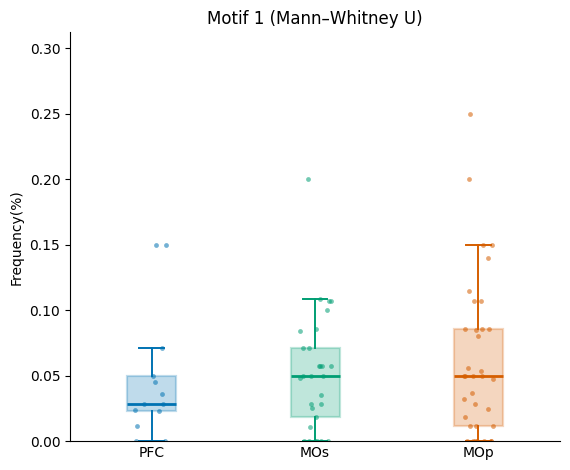

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' sin

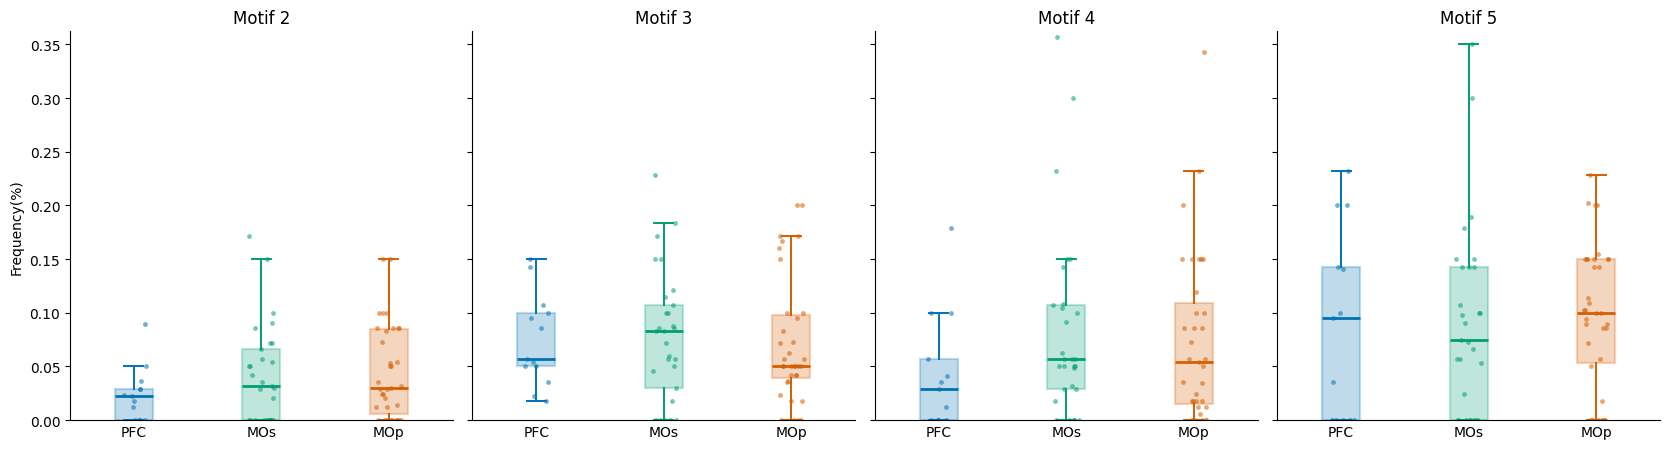

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' sin

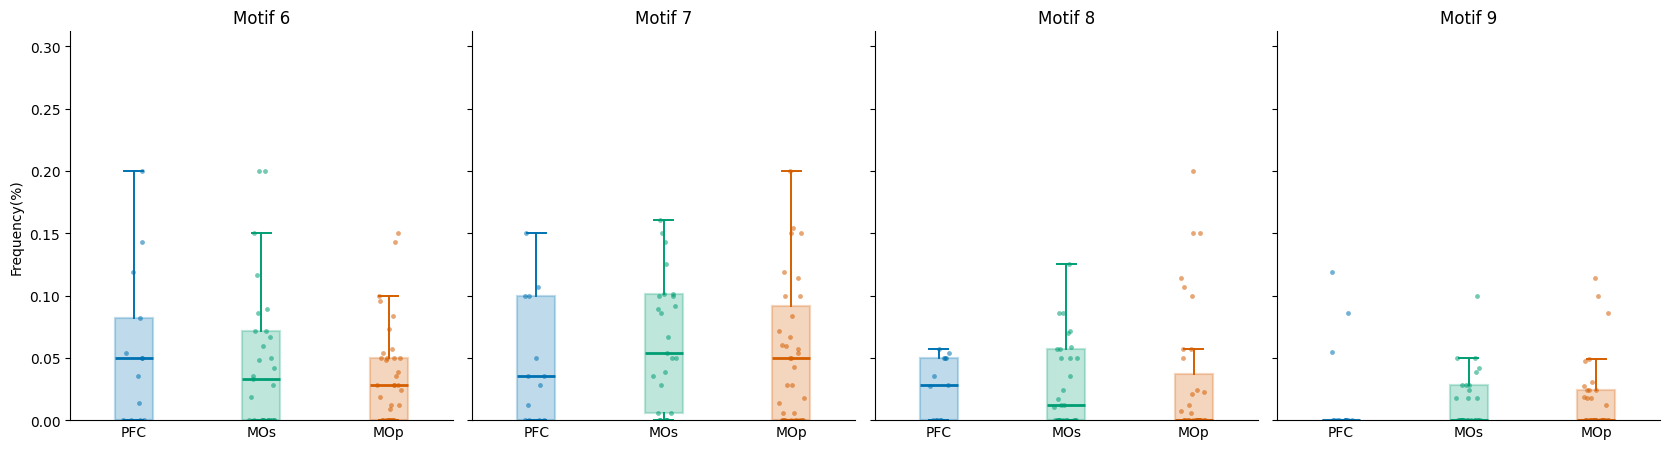

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_20623/4287003461.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' sin

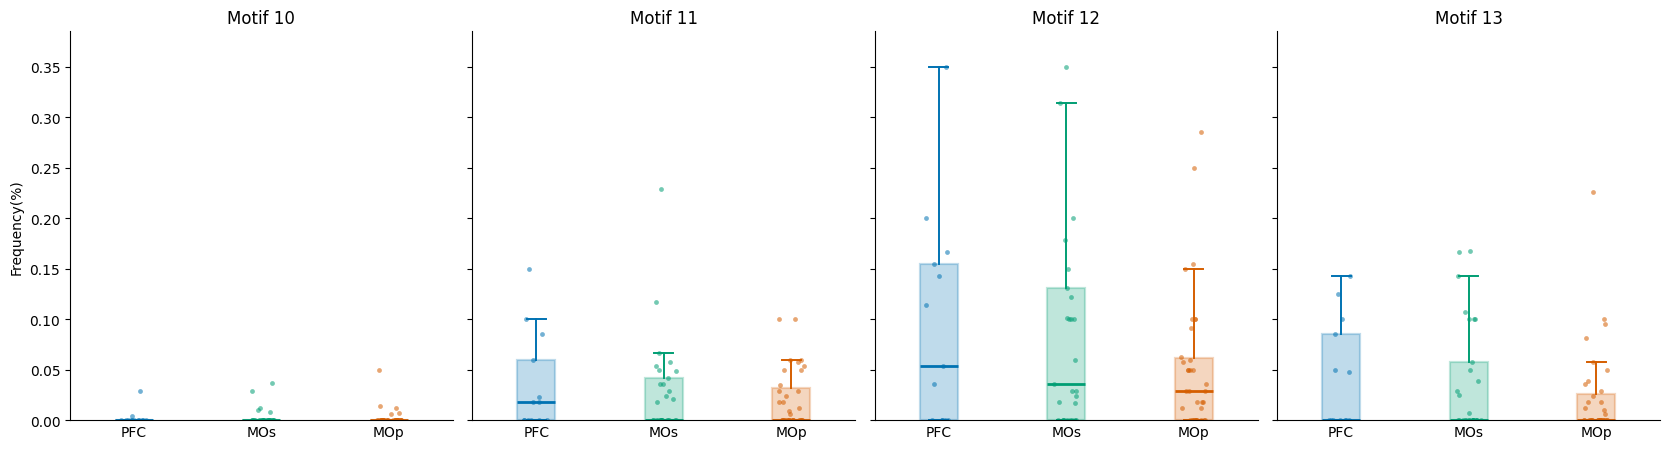

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# ===== 0) 前提：你已有 all_stats_df；并且也有 sc / names / df =====
# ============================================================
edge_thr = 0.0
LCC_MIN  = 6
use_ratio = True  # True: real/cn3；False: 原始 real

# 三个脑区配色（Okabe-Ito）
colors = {"PFC": "#0072B2", "MOp": "#D55E00", "MOs": "#009E73"}

# 顺序改成：PFC -> MOs -> MOp
groups = ["PFC", "MOs", "MOp"]

pairs = [(0, 1), (0, 2), (1, 2)]
rng = np.random.default_rng(0)

# robust ylim：忽略离群值用的分位数（不想忽略就把它们设成 0/1）
q_low, q_high = 0.02, 0.98

# 输出 svg 文件名前缀（会保存4张：Motif1、Motif2-5、6-9、10-13）
out_prefix = "cloneWithin_between"

# ============================================================
# ===== 1) 先算每个 clone 的 LCC（clone 子图：有向当无向）=====
# ============================================================
if "name" in df.columns:
    id_col = "name"
elif "Unnamed: 0" in df.columns:
    id_col = "Unnamed: 0"
else:
    raise ValueError("df 里找不到 neuron id 列（name / Unnamed: 0）")

names = np.asarray([str(x) for x in names], dtype=str)
meta = df.copy()
meta[id_col] = meta[id_col].astype(str)
meta = meta.set_index(id_col)

clone_arr = meta.reindex(names)["clone"].to_numpy()
valid = ~pd.isna(clone_arr)
uniq_clones = pd.unique(clone_arr[valid])

lcc_map = {}
for cl in uniq_clones:
    idxs = np.flatnonzero(valid & (clone_arr == cl))
    if idxs.size < 2:
        lcc_map[cl] = 0
        continue
    A_sub = sc[np.ix_(idxs, idxs)]
    B = (A_sub > edge_thr)
    np.fill_diagonal(B, False)
    U = B | B.T
    n = U.shape[0]
    seen = np.zeros(n, dtype=bool)
    best = 0
    for s in range(n):
        if seen[s]:
            continue
        stack = [s]
        seen[s] = True
        cnt = 0
        while stack:
            v = stack.pop()
            cnt += 1
            for u in np.flatnonzero(U[v]):
                if not seen[u]:
                    seen[u] = True
                    stack.append(u)
        if cnt > best:
            best = cnt
    lcc_map[cl] = int(best)

# ============================================================
# ===== 2) region -> group + 过滤 LCC<6 的 clone =====
# ============================================================
def map_region_to_group(r):
    r = str(r).strip()
    if r == "" or r.lower() == "nan":
        return np.nan
    if r.startswith(("ACA", "PL", "FRP", "ORB")):
        return "PFC"
    if r.startswith("MOp"):
        return "MOp"
    if r.startswith("MOs"):
        return "MOs"
    return np.nan


# p：三位有效数字，但强制小数展示（不用科学计数法）

df3 = all_stats_df.copy()
df3["group"] = df3["region"].map(map_region_to_group)
df3 = df3[df3["group"].isin(groups)].copy()
df3["lcc"] = df3["clone"].map(lcc_map).fillna(0).astype(int)
df3 = df3[df3["lcc"] >= LCC_MIN].copy()

print(f"过滤后 clone 行数: {len(df3)}（只保留 LCC>={LCC_MIN}）")
print(df3["group"].value_counts())

# ============================================================
# ===== 3) 指标：real 或 real/cn3 =====
# ============================================================
motif_cols = [f"real_Motif {i}" for i in range(1, 14)]
if use_ratio:
    denom = df3["c_n^3"].replace(0, np.nan).to_numpy()
    df3.loc[:, motif_cols] = df3[motif_cols].to_numpy() / denom[:, None]
    ylab = "Frequency(%)"
else:
    ylab = "real motif count"

# ============================================================
# ===== 4) 数据收集 + robust y范围（忽略离群值）=====
# ============================================================
def _collect_data(col):
    data = []
    for g in groups:
        arr = df3.loc[df3["group"] == g, col].astype(float).to_numpy()
        arr = arr[np.isfinite(arr)]
        data.append(arr)
    y_all = np.concatenate([a for a in data if a.size]) if any(a.size for a in data) else np.array([0.0])
    return data, y_all

def _robust_minmax(y, ql=q_low, qh=q_high):
    y = np.asarray(y, float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return 0.0, 1.0
    if y.size == 1:
        v = float(y[0])
        return v, v
    lo = float(np.quantile(y, ql))
    hi = float(np.quantile(y, qh))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = float(np.min(y)), float(np.max(y))
    if hi < lo:
        lo, hi = hi, lo
    return lo, hi

# ============================================================
# ===== 5) 画单个 motif：箱线+点（按组上色）+ M-W U
#          改动：ns / NA 的横线也不画（只对显著 p<0.05 画横线+文字）
#          其它要求保持不变
# ============================================================
def plot_one_motif(ax, col, title, ylim=None, y_max_for_bracket=None, pad_for_bracket=None):
    data, y_all = _collect_data(col)

    bp = ax.boxplot(
        data,
        labels=[f"{g}" for g in groups],   # 不要 (n=xx)
        showfliers=False,
        patch_artist=True
    )

    for i, g in enumerate(groups):
        c = colors[g]
        bp["boxes"][i].set(facecolor=c, edgecolor=c, alpha=0.25, linewidth=1.6)
        bp["medians"][i].set(color=c, linewidth=2.0)
        bp["whiskers"][2*i].set(color=c, linewidth=1.4); bp["whiskers"][2*i+1].set(color=c, linewidth=1.4)
        bp["caps"][2*i].set(color=c, linewidth=1.4);     bp["caps"][2*i+1].set(color=c, linewidth=1.4)

    for xi, (g, arr) in enumerate(zip(groups, data), start=1):
        if arr.size:
            jitter = rng.uniform(-0.10, 0.10, size=arr.size)
            ax.scatter(np.full(arr.size, xi) + jitter, arr, s=12, color=colors[g], alpha=0.55, linewidths=0)

    ax.set_title(title)
    ax.set_ylabel(ylab)

    # y轴：robust自适应；但强制从0开始
    if ylim is None:
        y_min_r, y_max_r = _robust_minmax(y_all)
        pad = (y_max_r - y_min_r) * 0.35 if y_max_r > y_min_r else 1.0
        y_max_for_bracket = y_max_r
        pad_for_bracket = pad
        ax.set_ylim(0.0, y_max_r + 1.6 * pad)  # 先给空间
    else:
        ax.set_ylim(0.0, float(ylim[1]))
        if y_max_for_bracket is None or pad_for_bracket is None:
            y_min_r, y_max_r = _robust_minmax(y_all)
            pad = (y_max_r - y_min_r) * 0.35 if y_max_r > y_min_r else 1.0
            y_max_for_bracket = y_max_r
            pad_for_bracket = pad

    # 仅显著(p<0.05)才画括号+文字；ns/NA 不画横线
    base = y_max_for_bracket + 0.15 * pad_for_bracket
    step = 0.28 * pad_for_bracket
    drawn = 0
    for (a, b) in pairs:
        x, y = data[a], data[b]
        if x.size < 2 or y.size < 2:
            continue
        p = mannwhitneyu(x, y, alternative="two-sided", method="auto").pvalue
        if (not np.isfinite(p)) or (p >= 0.05):
            continue

        yy = base + drawn * step
        drawn += 1
        x1, x2 = a + 1, b + 1
        ax.plot([x1, x1, x2, x2],
                [yy, yy + 0.04 * pad_for_bracket, yy + 0.04 * pad_for_bracket, yy],
                lw=1.2, color="black")

        p_str = format_p_decimal_3sig(p)
        ax.text((x1 + x2) / 2, yy + 0.06 * pad_for_bracket,
                f"p={p_str} {p_to_star(p)}",
                ha="center", va="bottom", fontsize=9, color="black")

    # 如果确实画了显著括号，确保y上界足够（单图自适应时）
    if (ylim is None) and (drawn > 0):
        y0, y1 = ax.get_ylim()
        need = base + (drawn - 1) * step + 0.22 * pad_for_bracket
        if need > y1:
            ax.set_ylim(0.0, need)

    # 只保留左/下两个坐标轴
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 横坐标不要刻度线（保留标签）
    ax.tick_params(axis="x", which="both", length=0)

# ============================================================
# ===== 6) Motif 1：单独一张 + 保存svg =====
# ============================================================
fig, ax = plt.subplots(figsize=(5.8, 4.8))
plot_one_motif(ax, "real_Motif 1", "Motif 1 (Mann–Whitney U)")
plt.tight_layout()
fig.savefig(f"{out_prefix}_Motif1.svg", bbox_inches="tight")
plt.show()

# ============================================================
# ===== 7) Motif 2–13：三张图，每张 1×4；每行统一y轴（robust）+ 保存svg =====
# ============================================================
batches = [[2, 3, 4, 5], [6, 7, 8, 9], [10, 11, 12, 13]]

for batch in batches:
    # 本行(4个motif)的robust范围用于统一ylim
    y_stack = []
    for m in batch:
        _, y_all = _collect_data(f"real_Motif {m}")
        if y_all.size:
            y_stack.append(y_all)
    y_stack = np.concatenate(y_stack) if len(y_stack) else np.array([0.0])

    y_min_b, y_max_b = _robust_minmax(y_stack)
    pad_b = (y_max_b - y_min_b) * 0.35 if y_max_b > y_min_b else 1.0

    # 统一y轴：从0开始；上界给“可能出现的显著括号”留空间（最多3个）
    ylim_b = (0.0, y_max_b + 1.6 * pad_b)

    fig, axes = plt.subplots(1, 4, figsize=(16.8, 4.6), sharey=True)
    for ax, m in zip(axes, batch):
        plot_one_motif(
            ax,
            f"real_Motif {m}",
            f"Motif {m}",
            ylim=ylim_b,
            y_max_for_bracket=y_max_b,
            pad_for_bracket=pad_b
        )
        if ax is not axes[0]:
            ax.set_ylabel("")

    plt.tight_layout()
    fig.savefig(f"{out_prefix}_Motif{batch[0]}-{batch[-1]}.svg", bbox_inches="tight")
    plt.show()